# CH 6 - Data Mining as a Multiple Comparison Procedure

## Objectif pédagogique

Cette leçon explique pourquoi le **data mining** en trading peut être vu comme une **procédure de comparaisons multiples**, ou **MCP**.

L’idée centrale est simple : au lieu de tester une seule règle de trading, le chercheur teste un grand nombre de règles candidates, puis sélectionne celle qui obtient le meilleur score historique.

> Le data mining n’est pas seulement “tester beaucoup de choses”.
>
> C’est une procédure structurée : **définir un problème**, construire un **univers de solutions**, choisir une **mesure de mérite**, puis sélectionner le meilleur candidat.

Dans le cadre EBTA, cette idée est fondamentale, car elle explique à la fois la puissance du data mining et son danger principal : le **biais de minage de données**.

## 1. L’idée générale : chercher le meilleur candidat

Une **procédure de comparaisons multiples** consiste à comparer plusieurs solutions possibles à un même problème.

En trading, le problème peut être :

> “Quelle règle permet de générer la meilleure performance historique sur ce marché ?”

Pour répondre à cette question, on ne teste pas une seule règle.

On teste un **univers entier de règles candidates**.

Par exemple :

| Élément MCP | Application trading |
|---|---|
| **Problème** | Trouver une règle profitable |
| **Solutions candidates** | Moyennes mobiles, breakouts, RSI, engulfings, filtres horaires, paramètres différents |
| **Mesure de mérite** | Rendement moyen, Sharpe ratio, profit factor, drawdown ajusté |
| **Décision finale** | Sélectionner la règle avec le meilleur score |

Le point important est que la règle gagnante est un **maximum statistique**.

Elle n’est pas seulement “bonne”.

Elle est la meilleure parmi toutes celles qu’on a testées.

## 2. Formulation mathématique simple

Supposons que l’on teste $N$ règles de trading.

Chaque règle produit un score historique :

$$
S_1, S_2, S_3, \dots, S_N
$$

La règle sélectionnée est celle qui maximise le score :

$$
S_{\max} = \max(S_1, S_2, S_3, \dots, S_N)
$$

En trading EBTA, ce score peut être :

$$
S_i = \text{Sharpe Ratio de la règle } i
$$

ou encore :

$$
S_i = \text{rendement moyen de la règle } i
$$

> Le piège est ici : plus $N$ augmente, plus il devient probable qu’une règle affiche un excellent score **par hasard**.

Autrement dit, même si toutes les règles sont sans talent réel, il y aura souvent une règle qui semble brillante simplement parce qu’on a organisé un grand concours.

## 3. Analogie : le concours de recrutement du capital

Imagine que ton capital organise un concours.

Il dit :

> “Je cherche une stratégie capable de me faire gagner de l’argent.”

Tu reçois alors des milliers de candidats :

- une règle RSI 14 ;
- une règle RSI 21 ;
- une règle moyenne mobile 20/50 ;
- une règle breakout ;
- une règle engulfing ;
- une règle avec filtre VWAP ;
- une règle avec filtre horaire ;
- une règle avec stop fixe ;
- une règle avec trailing stop ;
- etc.

Chaque candidat passe un examen : le **backtest**.

À la fin, tu sélectionnes celui qui obtient la meilleure note.

Le problème est que le meilleur candidat peut avoir réussi l’examen grâce à :

- un vrai talent prédictif ;
- une coïncidence favorable ;
- un alignement accidentel avec la période testée ;
- une simple chance statistique.

> L’Eurêka : le data mining est puissant parce qu’il permet de découvrir des stratégies.
>
> Mais il est dangereux parce que le gagnant du concours est naturellement favorisé par la chance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Hypothèse pédagogique :
# Toutes les règles sont en réalité sans edge.
# Leur performance observée est uniquement du bruit.
n_rules = 500
n_days = 252

# Rendements aléatoires quotidiens pour 500 règles sans talent réel.
# Moyenne vraie = 0.
returns = np.random.normal(loc=0.0, scale=0.01, size=(n_days, n_rules))

# Score de mérite : rendement moyen annualisé observé.
mean_daily_returns = returns.mean(axis=0)
annualized_returns = mean_daily_returns * 252

results = pd.DataFrame({
    "rule_id": np.arange(1, n_rules + 1),
    "annualized_return": annualized_returns
})

best_rule = results.loc[results["annualized_return"].idxmax()]

print("Nombre de règles testées :", n_rules)
print("Meilleure règle trouvée :", int(best_rule["rule_id"]))
print("Rendement annualisé observé de la meilleure règle :", round(best_rule["annualized_return"] * 100, 2), "%")
print("Rendement réel attendu de toutes les règles : 0 %")

Nombre de règles testées : 500
Meilleure règle trouvée : 452
Rendement annualisé observé de la meilleure règle : 53.96 %
Rendement réel attendu de toutes les règles : 0 %


## 4. Interprétation de la simulation

Dans cette simulation, aucune règle n’a de vrai pouvoir prédictif.

La moyenne réelle de chaque règle est :

$$
\mu = 0
$$

Donc, en théorie, aucune règle ne devrait être considérée comme profitable.

Pourtant, après avoir testé 500 règles, une règle ressort presque toujours avec une performance positive impressionnante.

Pourquoi ?

Parce qu’on ne regarde pas une règle prise au hasard.

On regarde la **meilleure règle parmi 500**.

C’est exactement le mécanisme du **biais de sélection**.

> Le maximum d’un grand ensemble de résultats aléatoires paraît souvent exceptionnel, même quand tous les candidats sont sans talent.

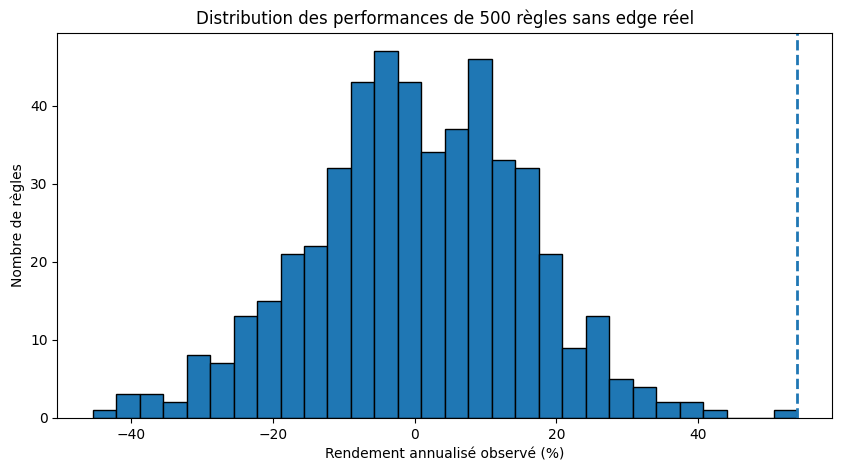

In [2]:
plt.figure(figsize=(10, 5))
plt.hist(results["annualized_return"] * 100, bins=30, edgecolor="black")
plt.axvline(best_rule["annualized_return"] * 100, linestyle="--", linewidth=2)
plt.title("Distribution des performances de 500 règles sans edge réel")
plt.xlabel("Rendement annualisé observé (%)")
plt.ylabel("Nombre de règles")
plt.show()

## 5. Ce que le graphique doit te faire voir

Le graphique montre la distribution des scores obtenus par des règles qui n’ont pourtant aucun edge réel.

La majorité des règles tourne autour de $0\%$.

Mais certaines règles finissent très à droite de la distribution.

Ce sont les **gagnants apparents**.

Leur performance n’est pas forcément la preuve d’un edge.

Elle peut être simplement la conséquence de cette logique :

$$
\text{beaucoup de tests} + \text{sélection du meilleur} = \text{résultat gonflé par la chance}
$$

> Voilà le cœur du problème : le backtest du meilleur candidat n’est pas une estimation neutre de sa performance future.
>
> Il est contaminé par le fait qu’il a été sélectionné parce qu’il était le meilleur.

In [3]:
def simulate_best_score(n_rules, n_days=252, n_simulations=1000):
    best_scores = []

    for _ in range(n_simulations):
        returns = np.random.normal(loc=0.0, scale=0.01, size=(n_days, n_rules))
        annualized = returns.mean(axis=0) * 252
        best_scores.append(annualized.max())

    return np.array(best_scores)

rule_counts = [1, 10, 50, 100, 500, 1000]
summary = []

for count in rule_counts:
    best_scores = simulate_best_score(count)
    summary.append({
        "Nombre de règles testées": count,
        "Meilleur rendement annualisé moyen observé (%)": best_scores.mean() * 100,
        "95e percentile du meilleur score (%)": np.percentile(best_scores, 95) * 100
    })

summary_df = pd.DataFrame(summary)
summary_df

,Nombre de règles testées,Meilleur rendement annualisé moyen observé (%),95e percentile du meilleur score (%)
0,1,-0.199007,25.210265
1,10,23.851863,40.449798
2,50,35.729029,48.954258
3,100,40.179121,53.071326
4,500,47.965071,58.978405
5,1000,51.393699,60.997514


## 6. Le vrai choc : plus tu testes, plus le meilleur résultat monte

La table précédente montre une réalité très importante.

Quand on augmente le nombre de règles testées, le meilleur score observé augmente naturellement.

Même si toutes les règles sont sans edge.

C’est le même phénomène que lancer beaucoup de dés :

- avec un seul lancer, obtenir un 6 n’est pas garanti ;
- avec 100 lancers, obtenir au moins un 6 devient presque certain ;
- avec 1000 lancers, tu obtiens forcément des résultats qui semblent “spéciaux”.

En trading, c’est pareil.

Tester beaucoup de règles augmente les chances de trouver une règle qui semble excellente.

Mais cela ne prouve pas encore que cette règle a un pouvoir prédictif réel.

> L’Eurêka final : le data mining ne crée pas seulement des opportunités.
>
> Il crée aussi une illusion statistique : le meilleur backtest d’un grand univers est presque toujours trop optimiste.

## 7. Actions concrètes pour un trader EBTA

Pour utiliser le data mining sans tomber dans le piège, il faut appliquer une discipline stricte.

### Action 1 — Définir le problème avant de tester

Avant de lancer les backtests, écris clairement :

> “Je cherche une règle capable de prédire les rendements futurs sur tel marché, avec telle logique, sur telle unité de temps.”

Cela empêche de changer l’objectif après avoir vu les résultats.

### Action 2 — Choisir la mesure de mérite à l’avance

Il faut définir le score avant le test.

Par exemple :

| Objectif | Mesure possible |
|---|---|
| Maximiser la rentabilité brute | Rendement moyen |
| Maximiser le rendement ajusté au risque | **Sharpe ratio** |
| Réduire les drawdowns | Rendement / **Ulcer Index** |
| Favoriser la stabilité | Profit factor + drawdown maximal |

La mesure choisie devient la règle du jeu.

Changer la mesure après avoir vu les résultats revient à tricher sans s’en rendre compte.

### Action 3 — Traiter le gagnant comme suspect

La meilleure règle du backtest doit être considérée comme une hypothèse prometteuse, pas comme une vérité.

Elle doit ensuite être validée par :

- un test **out-of-sample** ;
- une correction du **data mining bias** ;
- une validation sur différents régimes de marché ;
- une analyse de robustesse des paramètres ;
- idéalement une procédure comme le **White’s Reality Check** ou une méthode équivalente.

### Action 4 — Ne jamais confondre découverte et validation

Le data mining sert à découvrir.

Mais il ne suffit pas pour valider.

| Étape | Question |
|---|---|
| Découverte | “Quelle règle semble intéressante ?” |
| Validation | “Cette règle a-t-elle vraiment un edge ?” |
| Exécution | “Puis-je la trader sans dévier ?” |

> En EBTA, le data mining est un moteur de recherche.
>
> La statistique inférentielle est le filtre qui sépare les vrais signaux des illusions.

## 8. À retenir absolument

- **Data mining = procédure de comparaisons multiples**.
- Une MCP repose sur **1 problème**, **1 univers de solutions**, **1 mesure de mérite**.
- Le but est de sélectionner la solution avec le score maximal.
- En trading, cela revient à tester beaucoup de règles et choisir le meilleur backtest.
- La règle sélectionnée est un **maximum statistique**.
- Plus l’univers testé est grand, plus le meilleur score est susceptible d’être gonflé par la chance.
- Le danger principal est le **biais de minage de données**.
- La solution n’est pas d’éviter le data mining, mais de corriger statistiquement ses effets.

> Le trader amateur voit le meilleur backtest et pense : “J’ai trouvé mon edge.”
>
> Le trader EBTA voit le meilleur backtest et pense : “J’ai trouvé un candidat. Maintenant, je dois prouver qu’il n’est pas un mirage.”

# Annexe — Texte source collé

### **CH 6 : DATA MINING - DATA MINING AS A MULTIPLE COMPARISON PROCEDURE**

Voici l’analyse technique du minage de données envisagé comme une procédure de comparaisons multiples (MCP), le cadre méthodologique qui transforme la recherche de signaux de trading en un processus de résolution de problèmes rigoureux,.

---

#### **(AJOUT) Idées clés :**
*   **Paradigme MCP :** Le minage de données repose sur l'approche de résolution de problèmes appelée procédure de comparaisons multiples.
*   **Les trois piliers :** Toute MCP exige un problème bien défini, un univers de solutions candidates et une mesure de mérite (scoring),.
*   **Objectif de sélection :** Le but ultime est d'identifier la solution qui produit la performance maximale selon le critère choisi.
*   **Application au trading :** En EBTA, cela consiste à tester un vaste ensemble de règles de trading et à sélectionner celle qui affiche le meilleur profit historique.

---

#### **Référence :**
*Data Mining as a Multiple Comparison Procedure* (Pages 264–265).

---

#### **Citation Directe :**
« Data mining is based on a problem solving approach called a multiple comparison procedure (MCP). The basic idea behind an MCP is to test many different solutions to the problem and pick the one that performs the best according to some criterion. » (Page 264).

---

#### **Vision Macro :**
L'enjeu est de transformer le trading, souvent perçu comme un art intuitif, en une discipline scientifique de recherche de solutions. David Aronson explique que le minage de données n'est pas une simple accumulation de tests, mais un processus structuré de compétition entre des idées. Le trader agit comme un ingénieur : il définit un cahier des charges et utilise la puissance de calcul pour isoler la stratégie qui y répond le mieux. Cette approche est productive car elle permet d'explorer des relations complexes inaccessibles à l'esprit humain.

---

#### **Vision Micro :**
La structure d'une MCP appliquée au minage de règles de trading se décompose en trois éléments obligatoires :

1.  **Le Problème :** Il s'agit de déterminer le timing optimal des positions longues (achat) et courtes (vente) sur un marché financier pour générer des profits.
2.  **L'Univers de Solutions :** C'est l'ensemble (ou l'espace) des règles candidates proposées par le technicien objectif. Cet univers peut varier d'une simple optimisation de paramètres à une recherche de règles complexes par induction,.
3.  **La Figure de Mérite :** C'est la fonction de notation qui quantifie la qualité de chaque candidat. Aronson cite comme exemples :
    *   Le rendement moyen sur la période de test.
    *   Le ratio de Sharpe.
    *   Le rendement par rapport à l'indice d'Ulcer (Ulcer Index).

Le processus s'achève par le backtest systématique de chaque règle de l'univers, la règle affichant le score le plus élevé étant sélectionnée comme la solution optimale,.

---

#### **(AJOUT) Résumé Simplifié :**
Le minage de données est comme organiser un grand concours de recrutement pour votre capital. Vous définissez le poste (le problème), vous recevez des milliers de CV (les stratégies candidates), et vous faites passer un examen (le backtest). À la fin, vous engagez celui qui a eu la meilleure note (la figure de mérite). C'est une méthode de recherche très efficace, mais elle cache un piège : le champion a pu obtenir sa note par chance.

---

#### **Actions Concrètes :**
*   **Définir strictement la mesure de succès :** Choisissez votre indicateur de performance (ex: Ratio de Sharpe) *avant* de lancer les tests pour éviter de changer les règles en cours de route,.
*   **Constituer un univers de recherche vaste :** Plus vous testez de règles candidates, plus vous augmentez vos chances de trouver un signal réellement prédictif, à condition de corriger le biais ensuite,.
*   **Automatiser la comparaison :** Utilisez des algorithmes informatiques car l'esprit humain est incapable de gérer les multiples variables et le "bruit" des marchés financiers.

---

#### **(AJOUT) À retenir absolument :**
*   **Minage de données = MCP** (Multiple Comparison Procedure).
*   Nécessite : **1 Problème / 1 Univers / 1 Mesure**,.
*   La règle sélectionnée est le **Maximum Statistique** de l'univers testé.
*   C'est la méthode la plus productive pour la **découverte de connaissances** en trading.
*   Attention : la sélection du "meilleur" est la source directe du **biais de minage de données**,.

J'ai terminé l'analyse de la section sur le minage de données en tant que procédure de comparaisons multiples selon le protocole EBTA.